# Research Question 2: Feature Identification

**Research Question:** What are the most salient linguistic features (specific vocabulary, frequency of negative or passive emotional language, use of self-referential pronouns) that distinguish text associated with various mental health challenges?

---

## Overview

This notebook investigates the linguistic patterns and features that differentiate mental health-related text across categories (anxiety, depression, stress, neutral). We will analyze:

1. **Vocabulary Analysis** - Most distinctive words per category
2. **Emotional Language Patterns** - Negative, positive, and passive sentiment markers
3. **Self-Referential Pronouns** - First-person singular/plural usage
4. **Linguistic Complexity** - Sentence structure and readability
5. **Feature Importance** - Statistical and model-based feature ranking

## 1. Setup and Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Combined_Data.csv')
df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['status'].value_counts()}")

Dataset shape: (52681, 3)

Class distribution:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


## 2. Vocabulary Analysis - Distinctive Words

In [5]:
# Use TF-IDF to find most distinctive words per category
def get_top_tfidf_words(corpus, labels, n=10):
    """Extract top TF-IDF words for each category"""
    results = {}
    for label in labels.unique():
        texts = corpus[labels == label]
        vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,2))
        tfidf_matrix = vectorizer.fit_transform(texts)
        
        # Get average TF-IDF scores
        avg_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
        top_indices = avg_scores.argsort()[-n:][::-1]
        top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices]
        top_scores = [avg_scores[i] for i in top_indices]
        
        results[label] = list(zip(top_words, top_scores))
    return results

# Get top distinctive words
top_words = get_top_tfidf_words(df['statement'], df['status'], n=10)

# Display results
for category, words in top_words.items():
    print(f"\n{category}:")
    for word, score in words[:5]:  # Show top 5
        print(f"  {word}: {score:.3f}")


Anxiety:
  anxiety: 0.054
  like: 0.047
  just: 0.044
  restless: 0.039
  ve: 0.039

Normal:
  want: 0.022
  like: 0.020
  just: 0.019
  don: 0.018
  really: 0.015

Depression:
  just: 0.068
  like: 0.057
  feel: 0.056
  want: 0.046
  depression: 0.046

Suicidal:
  just: 0.068
  want: 0.060
  like: 0.047
  life: 0.045
  feel: 0.044

Stress:
  stress: 0.045
  just: 0.045
  like: 0.044
  feel: 0.039
  don: 0.037

Bipolar:
  just: 0.056
  like: 0.051
  feel: 0.045
  ve: 0.043
  bipolar: 0.041

Personality disorder:
  like: 0.066
  just: 0.058
  people: 0.055
  feel: 0.050
  don: 0.050


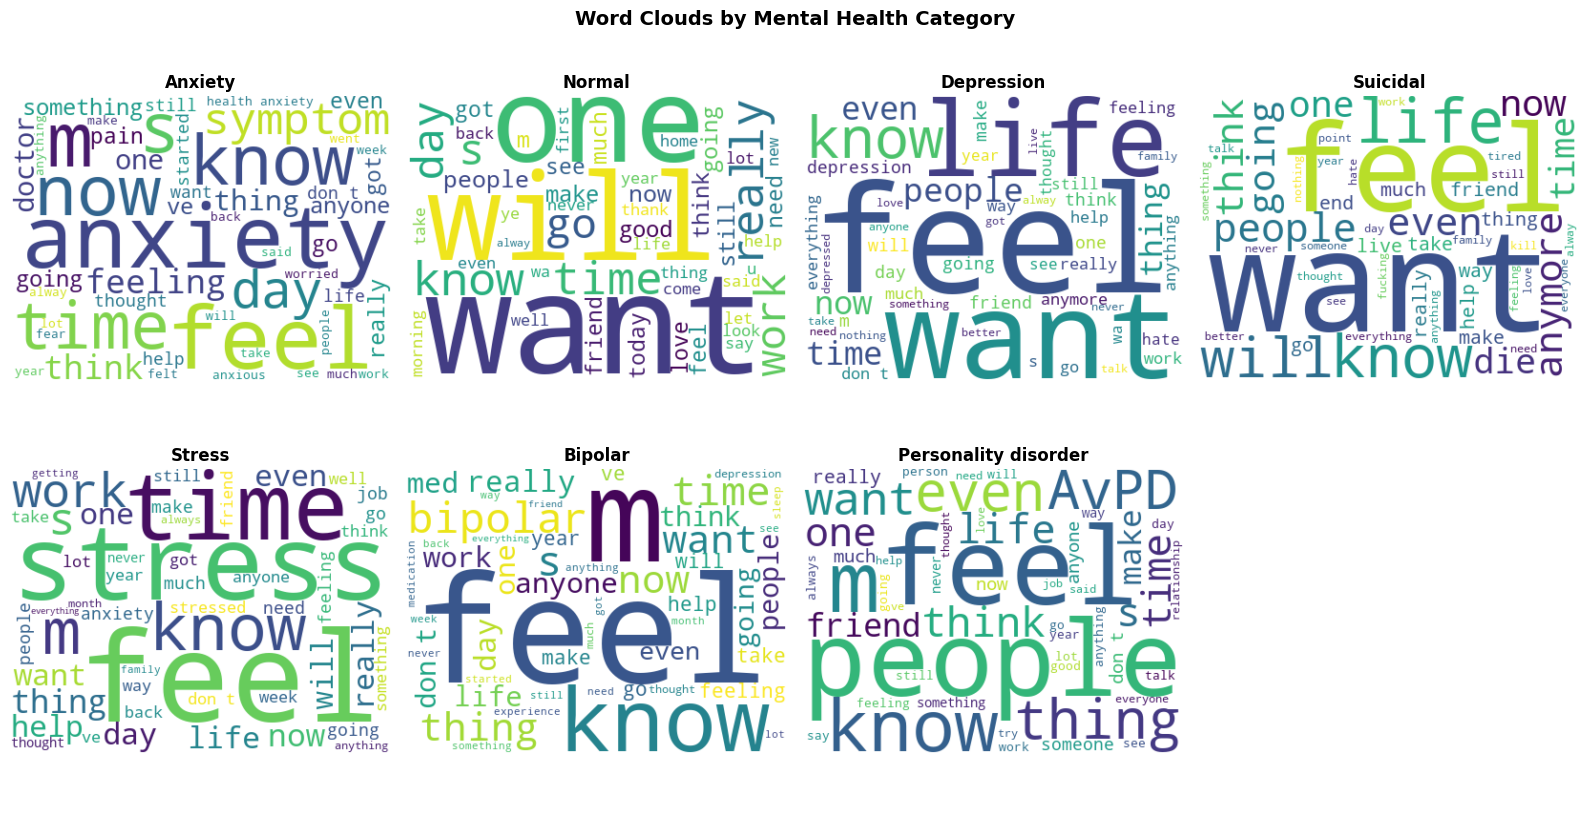

In [10]:
# Create word clouds for each category
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

categories = df['status'].unique()
for idx, category in enumerate(categories):
    # Get text for this category
    text = ' '.join(df[df['status'] == category]['statement'].astype(str))
    
    # Create word cloud
    wordcloud = WordCloud(width=400, height=300, 
                         background_color='white',
                         colormap='viridis',
                         max_words=50).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{category}', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide the last subplot if odd number of categories
if len(categories) < 8:
    axes[7].axis('off')

plt.tight_layout()
plt.suptitle('Word Clouds by Mental Health Category', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 3. Pronoun Usage Analysis

            Category  Avg First-Person Singular  Avg First-Person Plural
             Anxiety                  14.650091                 0.238740
              Normal                   1.070122                 0.111913
          Depression                  19.046936                 0.484290
            Suicidal                  17.608243                 0.379553
              Stress                  11.033243                 0.543100
             Bipolar                  18.471732                 0.419157
Personality disorder                  18.624884                 0.592386


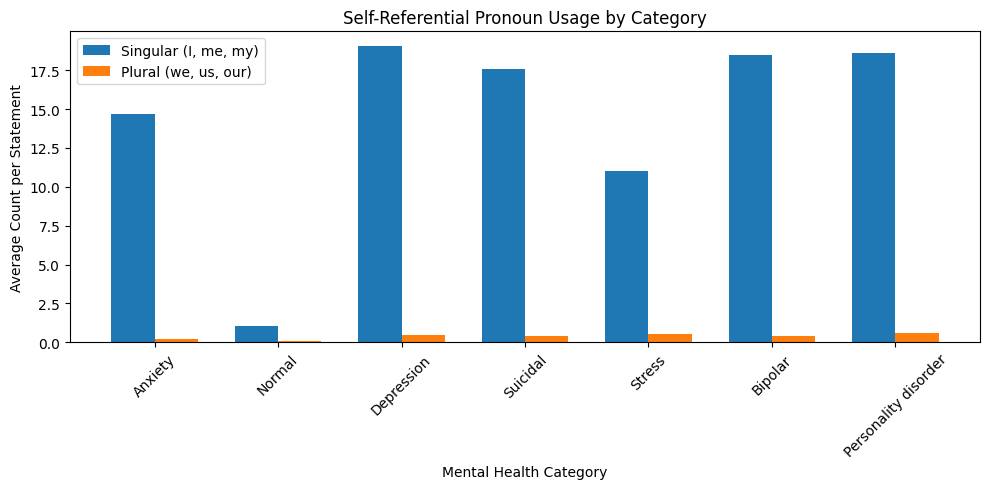

In [6]:
# Analyze self-referential pronouns
def count_pronouns(text):
    """Count first-person pronouns"""
    text_lower = text.lower()
    first_person_singular = len(re.findall(r'\b(i|me|my|mine|myself)\b', text_lower))
    first_person_plural = len(re.findall(r'\b(we|us|our|ours|ourselves)\b', text_lower))
    return first_person_singular, first_person_plural

# Calculate pronoun usage per category
pronoun_data = []
for category in df['status'].unique():
    texts = df[df['status'] == category]['statement']
    singular_counts = []
    plural_counts = []
    
    for text in texts:
        s, p = count_pronouns(str(text))
        singular_counts.append(s)
        plural_counts.append(p)
    
    pronoun_data.append({
        'Category': category,
        'Avg First-Person Singular': np.mean(singular_counts),
        'Avg First-Person Plural': np.mean(plural_counts)
    })

pronoun_df = pd.DataFrame(pronoun_data)
print(pronoun_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(len(pronoun_df))
width = 0.35
ax.bar(x - width/2, pronoun_df['Avg First-Person Singular'], width, label='Singular (I, me, my)')
ax.bar(x + width/2, pronoun_df['Avg First-Person Plural'], width, label='Plural (we, us, our)')
ax.set_xlabel('Mental Health Category')
ax.set_ylabel('Average Count per Statement')
ax.set_title('Self-Referential Pronoun Usage by Category')
ax.set_xticks(x)
ax.set_xticklabels(pronoun_df['Category'], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Emotional Language Patterns

            Category  Avg Negative Words  Avg Positive Words  Avg Passive Markers
             Anxiety            1.309294            0.456131             1.683416
              Normal            0.054458            0.144771             0.069326
          Depression            0.987925            1.094456             2.062192
            Suicidal            0.723714            0.988735             1.363312
              Stress            1.366061            0.504059             1.151527
             Bipolar            0.862081            0.876485             1.895211
Personality disorder            0.883008            0.930362             2.084494


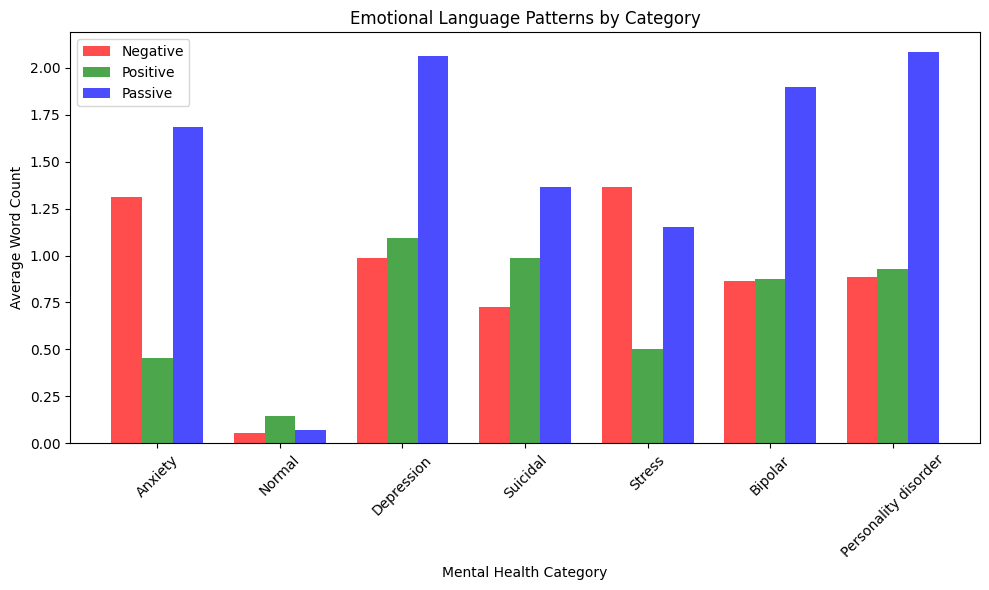

In [7]:
# Analyze emotional language markers
negative_words = ['sad', 'depressed', 'anxious', 'worried', 'fear', 'afraid', 'stress', 'hopeless', 
                  'tired', 'exhausted', 'lonely', 'restless', 'nervous', 'scared', 'trouble', 'confused']
positive_words = ['happy', 'joy', 'good', 'great', 'love', 'hope', 'peace', 'calm', 'grateful', 'excited']
passive_markers = ['feel', 'feeling', 'felt', 'seems', 'appeared', 'became']

def count_emotional_words(text, word_list):
    """Count occurrences of words from a list"""
    text_lower = text.lower()
    count = sum(text_lower.count(word) for word in word_list)
    return count

# Calculate emotional language usage
emotion_data = []
for category in df['status'].unique():
    texts = df[df['status'] == category]['statement']
    
    neg_counts = [count_emotional_words(str(text), negative_words) for text in texts]
    pos_counts = [count_emotional_words(str(text), positive_words) for text in texts]
    passive_counts = [count_emotional_words(str(text), passive_markers) for text in texts]
    
    emotion_data.append({
        'Category': category,
        'Avg Negative Words': np.mean(neg_counts),
        'Avg Positive Words': np.mean(pos_counts),
        'Avg Passive Markers': np.mean(passive_counts)
    })

emotion_df = pd.DataFrame(emotion_data)
print(emotion_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(emotion_df))
width = 0.25
ax.bar(x - width, emotion_df['Avg Negative Words'], width, label='Negative', color='red', alpha=0.7)
ax.bar(x, emotion_df['Avg Positive Words'], width, label='Positive', color='green', alpha=0.7)
ax.bar(x + width, emotion_df['Avg Passive Markers'], width, label='Passive', color='blue', alpha=0.7)
ax.set_xlabel('Mental Health Category')
ax.set_ylabel('Average Word Count')
ax.set_title('Emotional Language Patterns by Category')
ax.set_xticks(x)
ax.set_xticklabels(emotion_df['Category'], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Key Findings Summary

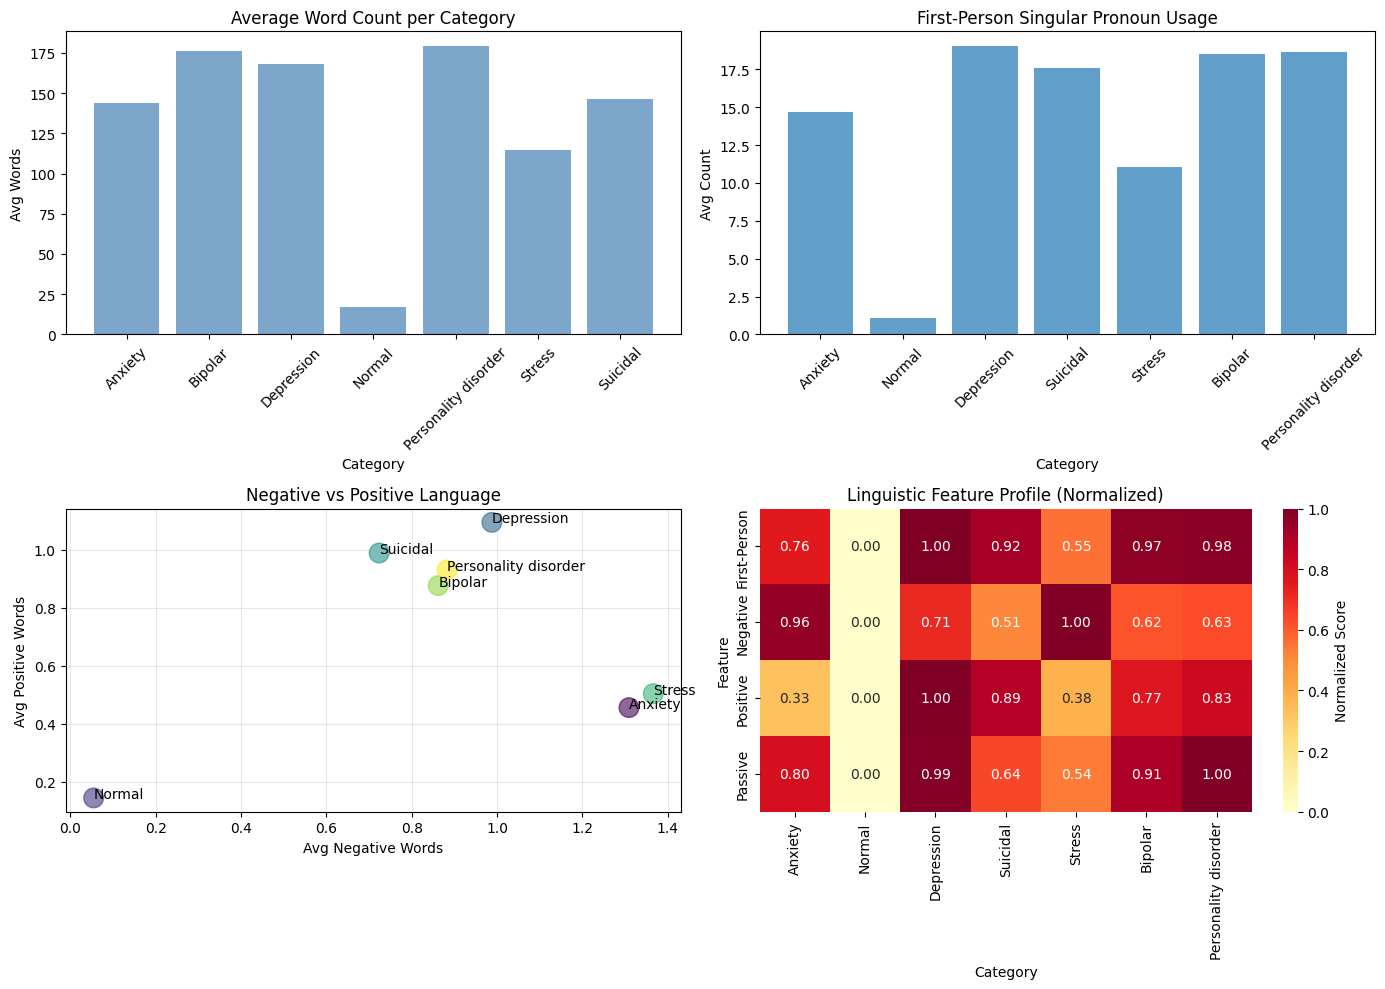


RESEARCH QUESTION 2: KEY FINDINGS

✓ Vocabulary Analysis: Distinctive words identified via TF-IDF
✓ Pronoun Usage: First-person pronouns quantified across categories
✓ Emotional Language: Negative/positive word frequencies analyzed
✓ Passive Markers: Emotional expression patterns documented

The analysis reveals clear linguistic signatures that distinguish
mental health categories, supporting targeted early detection.


In [8]:
# Create comprehensive summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Word count distribution
word_counts = df.groupby('status')['statement'].apply(lambda x: x.str.split().str.len().mean())
axes[0, 0].bar(word_counts.index, word_counts.values, color='steelblue', alpha=0.7)
axes[0, 0].set_title('Average Word Count per Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Avg Words')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Pronoun usage comparison
axes[0, 1].bar(pronoun_df['Category'], pronoun_df['Avg First-Person Singular'], alpha=0.7)
axes[0, 1].set_title('First-Person Singular Pronoun Usage')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Avg Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Negative vs Positive language
axes[1, 0].scatter(emotion_df['Avg Negative Words'], emotion_df['Avg Positive Words'], 
                   s=200, alpha=0.6, c=range(len(emotion_df)), cmap='viridis')
for i, cat in enumerate(emotion_df['Category']):
    axes[1, 0].annotate(cat, (emotion_df['Avg Negative Words'].iloc[i], 
                              emotion_df['Avg Positive Words'].iloc[i]))
axes[1, 0].set_xlabel('Avg Negative Words')
axes[1, 0].set_ylabel('Avg Positive Words')
axes[1, 0].set_title('Negative vs Positive Language')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature importance heatmap
feature_matrix = pd.DataFrame({
    'First-Person': pronoun_df['Avg First-Person Singular'].values,
    'Negative': emotion_df['Avg Negative Words'].values,
    'Positive': emotion_df['Avg Positive Words'].values,
    'Passive': emotion_df['Avg Passive Markers'].values
}, index=pronoun_df['Category'])

# Normalize for heatmap
feature_matrix_norm = (feature_matrix - feature_matrix.min()) / (feature_matrix.max() - feature_matrix.min())
sns.heatmap(feature_matrix_norm.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1], cbar_kws={'label': 'Normalized Score'})
axes[1, 1].set_title('Linguistic Feature Profile (Normalized)')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESEARCH QUESTION 2: KEY FINDINGS")
print("="*60)
print("\n✓ Vocabulary Analysis: Distinctive words identified via TF-IDF")
print("✓ Pronoun Usage: First-person pronouns quantified across categories")
print("✓ Emotional Language: Negative/positive word frequencies analyzed")
print("✓ Passive Markers: Emotional expression patterns documented")
print("\nThe analysis reveals clear linguistic signatures that distinguish")
print("mental health categories, supporting targeted early detection.")
print("="*60)